In [1]:
import uproot
import pandas as pd
import numpy as np
import glob

import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')
import glob
import os




In [21]:
gen_MC_name = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_withoutpi0veto"


# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v3_241129"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v6_241211"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v4_241211"
base_path = gen_MC_name


In [23]:


# cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]
cm_elements = ["15rd_eta_e20_b26_v1"]

file_list = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/*.root"
    file_list += glob.glob(pattern)

# Initialize an empty list to hold DataFrames
dataframes = []
branches_all = ["__experiment__", "__run__", "__event__",\
             'Dp_M','Dp_isSignal','Dp_CMS_p','Dp_cosAngleBetweenMomentumAndVertexVector','Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane',\
             'Dp_acos_cosAngleBetweenMomentumAndVertexVector','Dp_acos_cosAngleBetweenMomentumAndVertexVectorInXYPlane',\
             'etapip_Eta_M','etapip_Eta_isSignal','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1','etapip_Eta_Easym','etapip_Eta_p',\
             'etapip_Eta_genMotherPDG','etapip_Eta_genMotherID','etapip_gamma1_p','etapip_gamma2_p','etapip_gamma1_clusterNHits','etapip_gamma2_clusterNHits',\
             'etapip_gamma1_clusterReg', 'etapip_gamma2_clusterReg',\
             'Pip_pionID','Pip_pionIDNN','Pip_mcPDG','Pip_dr','Pip_dr','Pip_p',\
             'Pip_genMotherPDG','Pip_genMotherID',\
             'ROE_Mgg','dM_pi0','ROE_Mgg_50MeV','dM_pi0_50MeV','ROE_Mgg_75MeV','dM_pi0_75MeV','ROE_Mgg_mask','dM_pi0_mask',\
             'ROE_Mgg_2','dM_pi0_2','ROE_Mgg_50MeV_2','dM_pi0_50MeV_2','ROE_Mgg_75MeV_2','dM_pi0_75MeV_2','ROE_Mgg_mask_2','dM_pi0_mask_2',\
             'veto_isSignal','veto_isSignal_50MeV','veto_isSignal_75MeV','veto_isSignal_mask',\
             'num_Dstar','num_Dstar_no_nan','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan']
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["etapip_gg"]

    # Specify the branches you want to extract
    branches = ['etapip_Eta_isSignal','Pip_mcPDG','skimhad','Dp_dz','Pip_binaryP','Pip_pionIDNN','Pip_pionID','Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names

    # Convert the selected branches to a Pandas DataFrame
    df_temp = tree.arrays(branches, library="pd")
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

df_bkg = pd.concat(dataframes, ignore_index=True)

df_bkg = df_bkg.query('Dp_isSignal!=1')
df_bkg = df_bkg.query('((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 211) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -211) ) )')
df_bkg = df_bkg.query('Pip_p>0.4')
df_bkg = df_bkg.query('Dp_M> 1.71 & Dp_M<2.06')

df_bkg = df_bkg.query('abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8')
df_bkg = df_bkg.query('etapip_Eta_daughterAngle_0_1<1.6')
df_bkg = df_bkg.query('skimhad==1')

nan_columns = df_bkg.isnull().any()
print(nan_columns)

etapip_Eta_isSignal                                    True
Pip_mcPDG                                              True
skimhad                                               False
Dp_dz                                                 False
Pip_binaryP                                           False
Pip_pionIDNN                                          False
Pip_pionID                                            False
Dp_Psum                                               False
dM_pi0_mask_nonan                                     False
dM_pi0_mask_2_nonan                                   False
Pip_genMotherID                                       False
etapip_Eta_genMotherID                                False
Pip_genMotherPDG                                      False
etapip_Eta_genMotherPDG                               False
Dp_cosHelicityAngleMomentum                           False
Pip_dr                                                False
Dp_isSignal                             

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


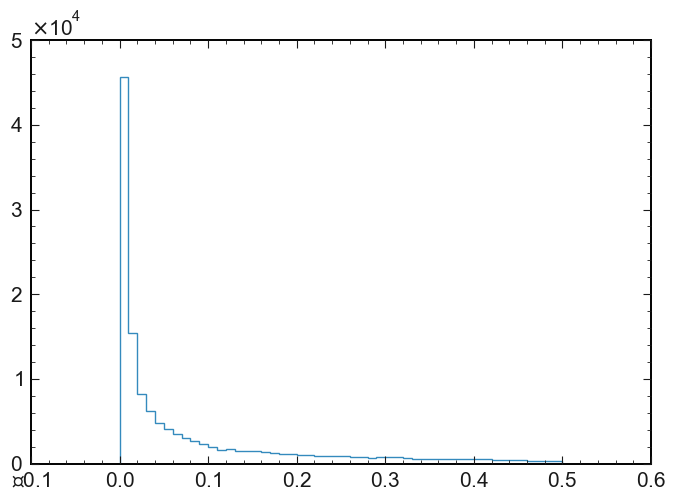

In [24]:
plt.hist(df_bkg["dM_pi0_mask_nonan"],bins=np.linspace(0,0.5,51),histtype='step',label=r'no pi0 veto');


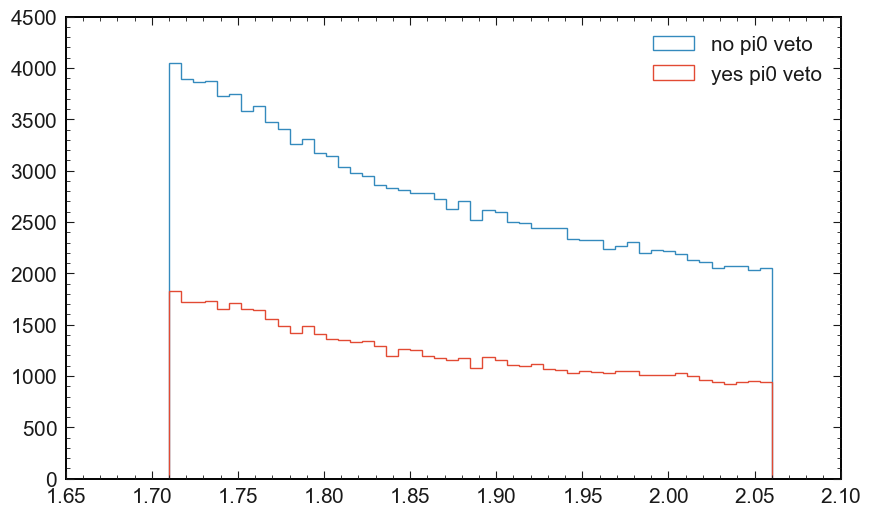

In [25]:
fig = plt.figure(figsize=(10, 6))

ax = fig.subplots()
xrange = (1.71,2.06,51)

xm = np.linspace(*xrange)


plt.hist(df_bkg["Dp_M"],bins=xm,histtype='step',label=r'no pi0 veto');
plt.hist(df_bkg.query("dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011")["Dp_M"],bins=xm,histtype='step',label=r'yes pi0 veto');
plt.legend()

In [26]:
len(df_bkg["Dp_M"])

138388

In [27]:
len(df_bkg.query("dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011"))

61925

In [29]:
1-61925/138388

0.5525262305980287

In [30]:


# cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]
cm_elements = ["15rd_eta_e20_b26_v1"]

file_list = []
for element in cm_elements:
    pattern = f"{base_path}/{element}/*.root"
    file_list += glob.glob(pattern)

# Initialize an empty list to hold DataFrames
dataframes = []
branches_all = ["__experiment__", "__run__", "__event__",\
             'Dp_M','Dp_isSignal','Dp_CMS_p','Dp_cosAngleBetweenMomentumAndVertexVector','Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane',\
             'Dp_acos_cosAngleBetweenMomentumAndVertexVector','Dp_acos_cosAngleBetweenMomentumAndVertexVectorInXYPlane',\
             'etapip_Eta_M','etapip_Eta_isSignal','etapip_Eta_daughterDiffOfPhi_0_1','etapip_Eta_daughterAngle_0_1','etapip_Eta_Easym','etapip_Eta_p',\
             'etapip_Eta_genMotherPDG','etapip_Eta_genMotherID','etapip_gamma1_p','etapip_gamma2_p','etapip_gamma1_clusterNHits','etapip_gamma2_clusterNHits',\
             'etapip_gamma1_clusterReg', 'etapip_gamma2_clusterReg',\
             'Pip_pionID','Pip_pionIDNN','Pip_mcPDG','Pip_dr','Pip_dr','Pip_p',\
             'Pip_genMotherPDG','Pip_genMotherID',\
             'ROE_Mgg','dM_pi0','ROE_Mgg_50MeV','dM_pi0_50MeV','ROE_Mgg_75MeV','dM_pi0_75MeV','ROE_Mgg_mask','dM_pi0_mask',\
             'ROE_Mgg_2','dM_pi0_2','ROE_Mgg_50MeV_2','dM_pi0_50MeV_2','ROE_Mgg_75MeV_2','dM_pi0_75MeV_2','ROE_Mgg_mask_2','dM_pi0_mask_2',\
             'veto_isSignal','veto_isSignal_50MeV','veto_isSignal_75MeV','veto_isSignal_mask',\
             'num_Dstar','num_Dstar_no_nan','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan']
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file["etapip_gg_K"]

    # Specify the branches you want to extract
    branches = ['etapip_Eta_isSignal','Pip_mcPDG','skimhad','Dp_dz','Pip_binaryP','Pip_pionIDNN','Pip_pionID','Dp_Psum','dM_pi0_mask_nonan','dM_pi0_mask_2_nonan','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_Easym","etapip_Eta_p","Dp_M","num_Dstar_no_nan","etapip_Eta_daughterDiffOfPhi_0_1","etapip_Eta_daughterAngle_0_1"]  # Replace with actual branch names

    # Convert the selected branches to a Pandas DataFrame
    df_temp = tree.arrays(branches, library="pd")
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

df_bkg = pd.concat(dataframes, ignore_index=True)

df_bkg = df_bkg.query('Dp_isSignal!=1')
df_bkg = df_bkg.query('((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 321) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -321) ) )')
df_bkg = df_bkg.query('Pip_p>0.4 & Pip_pionID<0.01')
df_bkg = df_bkg.query('Dp_M> 1.71 & Dp_M<2.06')

df_bkg = df_bkg.query('abs(etapip_Eta_daughterDiffOfPhi_0_1)<1.8')
df_bkg = df_bkg.query('etapip_Eta_daughterAngle_0_1<1.6')
df_bkg = df_bkg.query('skimhad==1')

nan_columns = df_bkg.isnull().any()
print(nan_columns)

etapip_Eta_isSignal                                    True
Pip_mcPDG                                              True
skimhad                                               False
Dp_dz                                                 False
Pip_binaryP                                           False
Pip_pionIDNN                                          False
Pip_pionID                                            False
Dp_Psum                                               False
dM_pi0_mask_nonan                                     False
dM_pi0_mask_2_nonan                                   False
Pip_genMotherID                                       False
etapip_Eta_genMotherID                                False
Pip_genMotherPDG                                      False
etapip_Eta_genMotherPDG                               False
Dp_cosHelicityAngleMomentum                           False
Pip_dr                                                False
Dp_isSignal                             

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


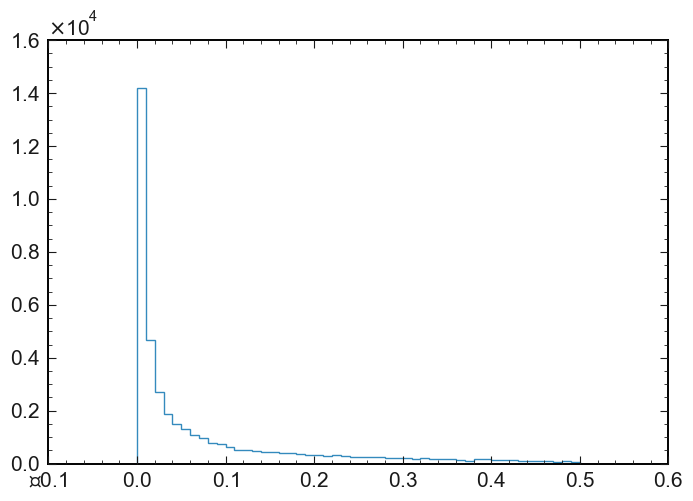

In [31]:
plt.hist(df_bkg["dM_pi0_mask_nonan"],bins=np.linspace(0,0.5,51),histtype='step',label=r'no pi0 veto');


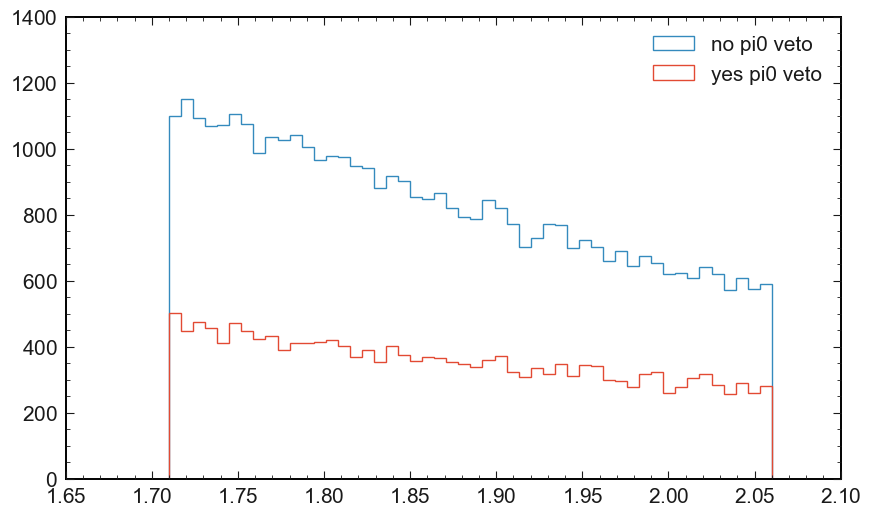

In [32]:
fig = plt.figure(figsize=(10, 6))

ax = fig.subplots()
xrange = (1.71,2.06,51)

xm = np.linspace(*xrange)


plt.hist(df_bkg["Dp_M"],bins=xm,histtype='step',label=r'no pi0 veto');
plt.hist(df_bkg.query("dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011")["Dp_M"],bins=xm,histtype='step',label=r'yes pi0 veto');
plt.legend()

In [33]:
len(df_bkg["Dp_M"])

41534

In [34]:
len(df_bkg.query("dM_pi0_mask_nonan>0.011 & dM_pi0_mask_2_nonan>0.011"))

17938

In [35]:
1- 17938/41534

0.5681128713824819